# TF-IDF Pipeline

## Import and Load Data

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv('../../data/raw/68k_multisector_amazon_products_final (1).csv', low_memory=False)
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'BSR non-null: {df["main_bsr_rank"].notna().sum():,}')

Loaded: 64,576 rows, 70 columns
BSR non-null: 46,936


## Train/Test Split

Since the same product (ASIN) can appear under multiple queries. A row-level split would let the same product appear in both train and test, meaning the model could "memorize" products rather than generalizing. Splitting by ASIN guarantees no product seen in training appears in test. 

In [2]:
# --- Step 0: Split BEFORE any text processing ---

unique_asins = df['asin'].unique()
train_asins, test_asins = train_test_split(unique_asins, test_size=0.2, random_state=42)
train_idx = df[df['asin'].isin(train_asins)].index
test_idx  = df[df['asin'].isin(test_asins)].index

# Verify no ASIN leaks across the split
assert len(set(df.loc[train_idx, 'asin']) & set(df.loc[test_idx, 'asin'])) == 0, "ASIN leakage detected!"
print(f'Train: {len(train_idx):,} rows  |  Test: {len(test_idx):,} rows')
print('Category distribution (train):')
print(df.loc[train_idx, 'category'].value_counts(normalize=True).round(3).to_string())

Train: 51,667 rows  |  Test: 12,909 rows
Category distribution (train):
category
home_kitchen              0.190
clothing_shoes_jewelry    0.124
electronics               0.079
office                    0.077
pets                      0.074
beauty_personal_care      0.072
consumables               0.059
baby                      0.058
health_household          0.058
sports_outdoors           0.057
tools_home_improvement    0.053
arts_crafts               0.050
automotive                0.049


## Text Assembly & Cleaning

Step 1: Build a single clean text column
We have two title columns: 
- 'title' (fallback)
- 'sd_title'

Step 2: Cleaning
- Lowercase everything
- Remove punctuation/special chars
- Keep numbers
- Collapse extra spaces

In [3]:
def clean_text(text):
    """Lowercase, strip non-alphanumeric chars, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# Prefer sd_title, fall back to title
df['text_clean'] = df['sd_title'].fillna(df['title']).fillna('')
df['text_clean'] = df['text_clean'].apply(clean_text)

# Also clean query the same way
df['query_clean'] = df['query'].fillna('').apply(clean_text)

# Sanity checks
print(f'Empty text_clean rows: {(df["text_clean"] == "").sum()}')
print(f'Empty query_clean rows: {(df["query_clean"] == "").sum()}')
print()

# Before/After Example
idx = df[df['title'] != df['sd_title']].dropna(subset=['sd_title']).index[1]
print('BEFORE (raw sd_title):')
print(f'  {df.loc[idx, "sd_title"][:120]}')
print('AFTER (text_clean):')
print(f'  {df.loc[idx, "text_clean"][:120]}')

Empty text_clean rows: 19
Empty query_clean rows: 0

BEFORE (raw sd_title):
  MACKENZIE-CHILDS Slotted Kitchen Spatula, Silicone Spatula for Cooking, Gray-and-White Sterling Check
AFTER (text_clean):
  mackenzie childs slotted kitchen spatula silicone spatula for cooking gray and white sterling check


# TF-IDF Vectorization

Two parts:
1. TF (Term Frequency): How often a word appears in one title.
2. IDF (Inverse Document Frequency): How rare a word is across ALL titles.

A word scores high only if it appears in THIS title AND is rare overall.

Parameters:
- max_features=500 → Keep only the 500 most informative words/phrases.
- ngram_range=(1, 2) → Include single words ("wireless") AND two-word phrases
- sublinear_tf=True → Use log(1 + TF) instead of raw TF
- min_df=5 → Ignore words that appear in fewer than 5 titles.
- max_df=0.95 → Ignore words appearing in >95% of titles.

In [4]:
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=5,
    max_df=0.95,
    stop_words='english'
)

# FIT on train only, TRANSFORM both
X_tfidf_train = tfidf.fit_transform(df.loc[train_idx, 'text_clean'])
X_tfidf_test  = tfidf.transform(df.loc[test_idx, 'text_clean'])

print(f'TF-IDF matrix shape (train): {X_tfidf_train.shape}')
print(f'TF-IDF matrix shape (test):  {X_tfidf_test.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_)} terms')
print()

# Show some of the learned vocabulary
vocab = tfidf.get_feature_names_out()
print(f'First 20 terms: {list(vocab[:20])}')
print(f'Last 20 terms:  {list(vocab[-20:])}')

TF-IDF matrix shape (train): (51667, 500)
TF-IDF matrix shape (test):  (12909, 500)
Vocabulary size: 500 terms

First 20 terms: ['10', '100', '11', '12', '13', '14', '15', '16', '17', '18', '20', '22', '24', '25', '30', '32', '36', '360', '40', '4k']
Last 20 terms:  ['water', 'water bottle', 'waterproof', 'wet', 'wheels', 'white', 'wide', 'wifi', 'window', 'windshield', 'winter', 'wipes', 'wireless', 'women', 'women men', 'womens', 'wood', 'work', 'workout', 'yoga']


# SVD Compression

We now have 500 columns. That's a lot for XGBoost — it can overfit (memorize noise instead of learning patterns), and many of those 500 words are correlated (e.g., "stainless" and "steel" almost always appear together).

TruncatedSVD — a technique that squishes 500 columns down to 100 columns while keeping as much information as possible by creating "profiles" and giving each product a score; also called LSA (Latent Semantic Analysis) when applied to text.


SVD shape (train): (51667, 100)
SVD shape (test):  (12909, 100)
Variance explained by 100 components: 49.8%

Variance explained per component (top 10):
  Component  0: 0.004  
  Component  1: 0.015  ██
  Component  2: 0.013  ██
  Component  3: 0.013  ██
  Component  4: 0.011  ██
  Component  5: 0.010  ██
  Component  6: 0.010  █
  Component  7: 0.009  █
  Component  8: 0.009  █
  Component  9: 0.009  █


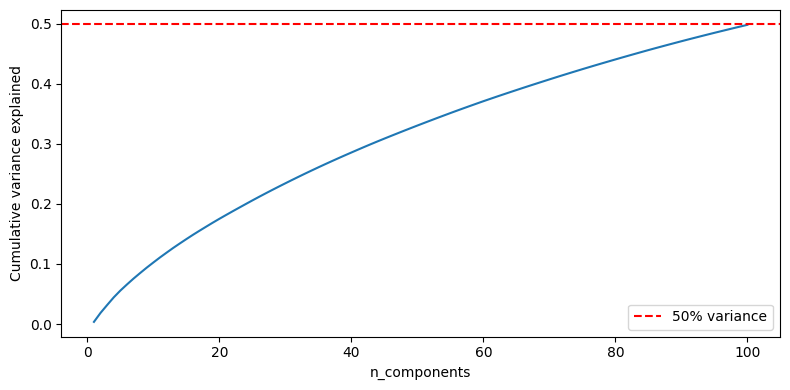

In [5]:
svd = TruncatedSVD(n_components=100, random_state=42)

# Fit on train, TRANSFORM both
X_svd_train = svd.fit_transform(X_tfidf_train)
X_svd_test  = svd.transform(X_tfidf_test)

# How much information did we keep?
explained = svd.explained_variance_ratio_.sum()
print(f'SVD shape (train): {X_svd_train.shape}')
print(f'SVD shape (test):  {X_svd_test.shape}')
print(f'Variance explained by {svd.n_components} components: {explained:.1%}')
print()

# How much each component contributes
print('Variance explained per component (top 10):')
for i, var in enumerate(svd.explained_variance_ratio_[:10]):
    bar = '█' * int(var * 200)
    print(f'  Component {i:2d}: {var:.3f}  {bar}')

# To find elbow point
import matplotlib.pyplot as plt
cumvar = svd.explained_variance_ratio_.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(range(1, 101), cumvar)
plt.axhline(0.5, color='red', ls='--', label='50% variance')
plt.xlabel('n_components'); plt.ylabel('Cumulative variance explained')
plt.legend(); plt.tight_layout(); plt.show()

In [6]:
# --- What does each SVD component represent? ---
# Each component is a weighted combination of TF-IDF terms.
# By looking at the terms with the highest weights, we can interpret
# what "topic" or "product type" each component captures.

terms = tfidf.get_feature_names_out()

print("Top terms per SVD component (top 10):\n")
component_labels = {}
for i, comp in enumerate(svd.components_[:15]):  # inspect first 15
    top_idx = comp.argsort()[-10:][::-1]
    top_terms = [terms[j] for j in top_idx]
    component_labels[f'tfidf_svd_{i}'] = top_terms
    print(f"  tfidf_svd_{i:2d}: {', '.join(top_terms)}")

Top terms per SVD component (top 10):

  tfidf_svd_ 0: storage, organizer, pack, black, set, home, women, large, men, office
  tfidf_svd_ 1: men, women, men women, running, high, workout, sports, women men, casual, yoga
  tfidf_svd_ 2: usb, light, led, lamp, portable, desk, power, battery, rechargeable, monitor
  tfidf_svd_ 3: dog, dogs, pet, cat, stainless, steel, stainless steel, water, medium, oz
  tfidf_svd_ 4: dog, dogs, large, medium, pet, small, toys, storage, organizer, toy
  tfidf_svd_ 5: steel, stainless, stainless steel, water, dog, black, desk, insulated, water bottle, coffee
  tfidf_svd_ 6: set, piece, high, women, home, yoga, desk, office, control, soft
  tfidf_svd_ 7: car, kit, brush, hair, tool, set, cleaning, men, cordless, drill
  tfidf_svd_ 8: women, high, yoga, workout, leggings, car, pants, control, bra, sports
  tfidf_svd_ 9: baby, diaper, bag, set, light, travel, kit, backpack, led, lamp
  tfidf_svd_10: oz, cleaner, lamp, light, cleaning, car, women, fl, fl oz, s

In [7]:
# --- Map Components to Themes ---
svd_component_themes = {
    'tfidf_svd_0':  'General household & storage (organizers, office, apparel)',
    'tfidf_svd_1':  'Athletic & activewear (running, workout, yoga, sports)',
    'tfidf_svd_2':  'Electronics & lighting (USB, LED, portable, rechargeable)',
    'tfidf_svd_3':  'Pet feeding & drinkware (dog/cat bowls, stainless steel, water)',
    'tfidf_svd_4':  'Pet accessories & toys (dogs, cats, size variants)',
    'tfidf_svd_5':  'Baby care & hygiene (diapers, wipes, cotton, soft goods)',
    'tfidf_svd_6':  'Home & yoga soft goods (sets, high-end, desk/office)',
    'tfidf_svd_7':  'Tools & grooming (car, drill, hair brush, cleaning kits)',
    'tfidf_svd_8':  'Menswear & office lighting (casual shoes, dress, desk lamp)',
    'tfidf_svd_9':  'Baby travel & lighting (diaper bags, backpacks, LED/lamp)',
    'tfidf_svd_10': 'Tech & kitchen sets (USB, PC, gaming, wireless, knives)',
    'tfidf_svd_11': 'Car safety & baby monitoring (dash cam, night vision, camera)',
    'tfidf_svd_12': 'Car & home waste management (trash bags, garbage, gallon)',
    'tfidf_svd_13': 'Bathroom & kitchen lighting (LED mirror, shower, curtain)',
    'tfidf_svd_14': 'Bathroom cleaning & travel (shower, brush, backpack, dish)',
}

print("SVD Component Reference Table:")
print(f"{'Component':<15} {'Top Terms / Theme'}")
print("-" * 60)
for comp, theme in svd_component_themes.items():
    print(f"{comp:<15} {theme}")

SVD Component Reference Table:
Component       Top Terms / Theme
------------------------------------------------------------
tfidf_svd_0     General household & storage (organizers, office, apparel)
tfidf_svd_1     Athletic & activewear (running, workout, yoga, sports)
tfidf_svd_2     Electronics & lighting (USB, LED, portable, rechargeable)
tfidf_svd_3     Pet feeding & drinkware (dog/cat bowls, stainless steel, water)
tfidf_svd_4     Pet accessories & toys (dogs, cats, size variants)
tfidf_svd_5     Baby care & hygiene (diapers, wipes, cotton, soft goods)
tfidf_svd_6     Home & yoga soft goods (sets, high-end, desk/office)
tfidf_svd_7     Tools & grooming (car, drill, hair brush, cleaning kits)
tfidf_svd_8     Menswear & office lighting (casual shoes, dress, desk lamp)
tfidf_svd_9     Baby travel & lighting (diaper bags, backpacks, LED/lamp)
tfidf_svd_10    Tech & kitchen sets (USB, PC, gaming, wireless, knives)
tfidf_svd_11    Car safety & baby monitoring (dash cam, night vision, c

## Query–Title Alignment Features

Idea
- The dataset tells us what the customer searched ("water bottle") and what the product title says. If the title closely matches the query, that product is more relevant to the search.

Observation from EDA
- From the EDA, we saw something interesting: products with LOWER overlap actually had BETTER (lower) BSR. That means top sellers have distinctive, brand-heavy titles — they don't need to keyword-stuff because they're already popular. Either way, it's a strong signal.

---

### 3 Features

1. Word Overlap Ratio: What fraction of query words appear in the title?

2. Cosine Similarity (TF-IDF based): More sophisticated than word overlap. Uses TF-IDF vectors to measure similarity. Two texts pointing in the same "direction" in word-space have high cosine similarity (close to 1.0). Unrelated texts → close to 0. This catches partial matches that word overlap misses.

3. Exact Substring Match (Binary): Does the full query appear word-for-word inside the title?

--- 

### Findings

- query_word_overlap: Most products contain nearly all query words in their title, expected since these are search results.
- query_cos_sim: Moderate similarity (0.42) with real variation — useful signal for the model.
- query_exact_match: 58% of products contain the exact query word-for-word, making it the strongest single interpretable feature for BSR.

In [8]:
# --- Feature 1: Word overlap ratio ---
def word_overlap(query, title):
    q_words = set(query.split())
    t_words = set(title.split())
    if not q_words:
        return 0.0
    return len(q_words & t_words) / len(q_words)

df['query_word_overlap'] = df.apply(
    lambda r: word_overlap(r['query_clean'], r['text_clean']), axis=1
)

# --- Feature 2: Cosine similarity using TF-IDF vectors ---
# Transform queries through the SAME fitted vectorizer
query_tfidf_all = tfidf.transform(df['query_clean'])
title_tfidf_all = tfidf.transform(df['text_clean'])

# For normalized TF-IDF vectors, dot product = cosine similarity.
from sklearn.preprocessing import normalize

query_norm = normalize(query_tfidf_all, norm='l2')
title_norm = normalize(title_tfidf_all, norm='l2')

# Multiply element-wise and sum across columns = row-wise cosine sim
df['query_cos_sim'] = np.array(query_norm.multiply(title_norm).sum(axis=1)).flatten()

# --- Feature 3: Exact substring match ---
df['query_exact_match'] = df.apply(
    lambda r: int(r['query_clean'] in r['text_clean']), axis=1
)

# --- Summary ---
print('=== Query-Title Alignment Features ===')
for col in ['query_word_overlap', 'query_cos_sim', 'query_exact_match']:
    print(f'\n{col}:')
    print(df[col].describe().round(3).to_string())

=== Query-Title Alignment Features ===

query_word_overlap:
count    64576.000
mean         0.825
std          0.307
min          0.000
25%          0.667
50%          1.000
75%          1.000
max          1.000

query_cos_sim:
count    64576.000
mean         0.418
std          0.238
min          0.000
25%          0.283
50%          0.457
75%          0.589
max          1.000

query_exact_match:
count    64576.000
mean         0.580
std          0.494
min          0.000
25%          0.000
50%          1.000
75%          1.000
max          1.000


# Structural Title Features

Capture patterns in titles that TF-IDF can't see. 

In [9]:
title_lower = df['text_clean']

# 1. Title length
df['title_char_count'] = title_lower.str.len()
df['title_word_count_feat'] = title_lower.str.split().str.len()

# 2. Count of tokens containing digits
#    More numeric tokens usually means more detailed product specs
df['n_numeric_tokens'] = title_lower.apply(
    lambda t: sum(1 for w in t.split() if any(c.isdigit() for c in w))
)

# 3. Does title start with a brand name?
df['has_brand_first'] = df['title'].fillna('').str.match(
    r'^[A-Z][A-Za-z]', na=False
).astype(int)

# 4. Pack/set/bundle mentions
df['n_pack_mentions'] = title_lower.str.count(
    r'\b(?:pack|set|piece|bundle|count|pcs)\b'
)

# 5. Has measurement/spec units — indicates detailed product listing
df['has_spec_units'] = title_lower.str.contains(
    r'\d+\s*(?:oz|ml|lb|kg|ft|inch|cm|mm|gal|qt|ct|watt|volt|amp)',
    regex=True
).astype(int)

# 6. Has dimensions
df['has_dimensions'] = title_lower.str.contains(
    r'\d+\s*x\s*\d+', regex=True
).astype(int)

# 7. Has color mentioned — indicates product variation
df['has_color'] = title_lower.str.contains(
    r'\b(?:black|white|red|blue|green|pink|grey|gray|silver|gold|brown|purple|orange|yellow)\b',
    regex=True
).astype(int)

# 8. Superlative/marketing word count — "premium", "ultra", etc.
df['n_superlatives'] = title_lower.str.count(
    r'\b(?:premium|ultra|professional|pro|deluxe|heavy duty|industrial|advanced|upgraded|luxury)\b'
)

# --- Summary ---
struct_features = [
    'title_char_count', 'title_word_count_feat', 'n_numeric_tokens',
    'has_brand_first', 'n_pack_mentions', 'has_spec_units',
    'has_dimensions', 'has_color', 'n_superlatives'
]

print('=== Structural Feature Summary ===')
print(df[struct_features].describe().round(2).to_string())

=== Structural Feature Summary ===
       title_char_count  title_word_count_feat  n_numeric_tokens  has_brand_first  n_pack_mentions  has_spec_units  has_dimensions  has_color  n_superlatives
count          64576.00               64576.00          64576.00          64576.0         64576.00        64576.00         64576.0   64576.00        64576.00
mean             146.35                  23.97              2.35              0.9             0.34            0.22             0.1       0.33            0.16
std               42.96                   7.26              2.32              0.3             0.63            0.42             0.3       0.47            0.43
min                0.00                   0.00              0.00              0.0             0.00            0.00             0.0       0.00            0.00
25%              118.00                  19.00              1.00              1.0             0.00            0.00             0.0       0.00            0.00
50%              

# Assemble & Export

Combine SVD components, alignment features, and structural features into one DF. Also added "split" col so modeling notebook knows which rows are train vs test without re-splitting.

In [11]:
# Build SVD columns for ALL rows
X_tfidf_all = tfidf.transform(df['text_clean'])
X_svd_all = svd.transform(X_tfidf_all)

svd_cols = [f'tfidf_svd_{i}' for i in range(svd.n_components)]
svd_df = pd.DataFrame(X_svd_all, index=df.index, columns=svd_cols)

# Alignment features
alignment_cols = ['query_word_overlap', 'query_cos_sim', 'query_exact_match']

# Structural features
struct_cols = [
    'title_char_count', 'title_word_count_feat', 'n_numeric_tokens',
    'has_brand_first', 'n_pack_mentions', 'has_spec_units',
    'has_dimensions', 'has_color', 'n_superlatives'
]

# Combine
nlp_features = pd.concat([
    df[['asin', 'category', 'main_bsr_rank', 'lowest_bsr_rank']],
    svd_df,
    df[alignment_cols],
    df[struct_cols],
], axis=1)

# Mark train/test split
nlp_features['split'] = 'test'
nlp_features.loc[train_idx, 'split'] = 'train'

# Summary
feature_cols = svd_cols + alignment_cols + struct_cols
print(f'Total NLP features: {len(feature_cols)}')
print(f'Output shape: {nlp_features.shape}')
print(f'Train rows: {(nlp_features["split"] == "train").sum():,}')
print(f'Test rows:  {(nlp_features["split"] == "test").sum():,}')
print(f'\nFeature columns:')
for i, col in enumerate(feature_cols):
    print(f'  {i+1:2d}. {col}')

# Save
output_path = '../../data/nlp_features_68k.parquet'
nlp_features.to_parquet(output_path, index=False)
print(f'\nSaved to: {output_path}')

Total NLP features: 112
Output shape: (64576, 117)
Train rows: 51,667
Test rows:  12,909

Feature columns:
   1. tfidf_svd_0
   2. tfidf_svd_1
   3. tfidf_svd_2
   4. tfidf_svd_3
   5. tfidf_svd_4
   6. tfidf_svd_5
   7. tfidf_svd_6
   8. tfidf_svd_7
   9. tfidf_svd_8
  10. tfidf_svd_9
  11. tfidf_svd_10
  12. tfidf_svd_11
  13. tfidf_svd_12
  14. tfidf_svd_13
  15. tfidf_svd_14
  16. tfidf_svd_15
  17. tfidf_svd_16
  18. tfidf_svd_17
  19. tfidf_svd_18
  20. tfidf_svd_19
  21. tfidf_svd_20
  22. tfidf_svd_21
  23. tfidf_svd_22
  24. tfidf_svd_23
  25. tfidf_svd_24
  26. tfidf_svd_25
  27. tfidf_svd_26
  28. tfidf_svd_27
  29. tfidf_svd_28
  30. tfidf_svd_29
  31. tfidf_svd_30
  32. tfidf_svd_31
  33. tfidf_svd_32
  34. tfidf_svd_33
  35. tfidf_svd_34
  36. tfidf_svd_35
  37. tfidf_svd_36
  38. tfidf_svd_37
  39. tfidf_svd_38
  40. tfidf_svd_39
  41. tfidf_svd_40
  42. tfidf_svd_41
  43. tfidf_svd_42
  44. tfidf_svd_43
  45. tfidf_svd_44
  46. tfidf_svd_45
  47. tfidf_svd_46
  48. tfid

# Reload & Verify

Loads parquet file and confirms everything saved correctly. 

In [12]:
# --- Load the NLP features we just built ---
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

nlp = pd.read_parquet('../../data/nlp_features_68k.parquet')
print(f'Loaded: {nlp.shape}')
print(f'Train: {(nlp["split"] == "train").sum():,}')
print(f'Test:  {(nlp["split"] == "test").sum():,}')
print(f'BSR non-null: {nlp["main_bsr_rank"].notna().sum():,}')

Loaded: (64576, 117)
Train: 51,667
Test:  12,909
BSR non-null: 46,936


# Baseline vs Full Comparison

Four models trained on the same ASIN-level split predicting log(BSR):

- **Baseline XGBoost** (9 structural features): R² = 0.0404
- **XGBoost interpretable** (12 alignment + structural features): R² = 0.0759
- **LightGBM interpretable** (12 alignment + structural features): R² = 0.0696
- **Full XGBoost** (112 features: 100 SVD + alignment + structural): R² = 0.3223

Adding query-title alignment to structural features nearly doubles R² (0.04 → 0.08). Adding TF-IDF/SVD vocabulary features pushes it to 0.32 — an 8x improvement over baseline. XGBoost outperforms LightGBM on the interpretable feature set, confirming it as the right model choice. 100 SVD components was selected after testing 200 and 300 showed negligible gains (0.3256 and 0.3240 respectively).

In [17]:
# Filter to rows that have BSR
nlp_ranked = nlp[nlp['main_bsr_rank'].notna()].copy()

# Log-transform the target
nlp_ranked['log_bsr'] = np.log1p(nlp_ranked['main_bsr_rank'])

# Split using the saved labels
train = nlp_ranked[nlp_ranked['split'] == 'train']
test  = nlp_ranked[nlp_ranked['split'] == 'test']

print(f'Ranked products — Train: {len(train):,}, Test: {len(test):,}')
print()

# Define feature groups
svd_cols = [f'tfidf_svd_{i}' for i in range(svd.n_components)]
alignment_cols = ['query_word_overlap', 'query_cos_sim', 'query_exact_match']
struct_cols = [
    'title_char_count', 'title_word_count_feat', 'n_numeric_tokens',
    'has_brand_first', 'n_pack_mentions', 'has_spec_units',
    'has_dimensions', 'has_color', 'n_superlatives'
]

# BASELINE: structural features only (similar to what the old pipeline had)
baseline_features = struct_cols

# FULL: everything
full_features = svd_cols + alignment_cols + struct_cols

# Train and evaluate both
y_train = train['log_bsr']
y_test  = test['log_bsr']

results = {}

for name, feature_list in [('Baseline (structural only)', baseline_features),
                            ('Full NLP (TF-IDF + alignment + structural)', full_features)]:
    
    X_train = train[feature_list].fillna(0)
    X_test  = test[feature_list].fillna(0)
    
    model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'RMSE': rmse, 'R²': r2, 'Features': len(feature_list)}
    print(f'{name}:')
    print(f'  Features: {len(feature_list)}')
    print(f'  RMSE (log-space): {rmse:.4f}')
    print(f'  R²: {r2:.4f}')
    print()

# INTERPRETABLE: alignment + structural only (no SVD)
interpretable_features = alignment_cols + struct_cols
X_train_interp = train[interpretable_features].fillna(0)
X_test_interp  = test[interpretable_features].fillna(0)

model_interp = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                             random_state=42, n_jobs=-1)
model_interp.fit(X_train_interp, y_train)
r2_interp = r2_score(y_test, model_interp.predict(X_test_interp))

# LIGHTGBM on interpretable features
from lightgbm import LGBMRegressor
model_lgbm = LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                            subsample=0.8, random_state=42, n_jobs=-1)
model_lgbm.fit(X_train_interp, y_train)
r2_lgbm = r2_score(y_test, model_lgbm.predict(X_test_interp))

# Improvement
baseline_r2 = results['Baseline (structural only)']['R²']
full_r2 = results['Full NLP (TF-IDF + alignment + structural)']['R²']
print(f'R² improvement: {baseline_r2:.4f} → {full_r2:.4f} ({(full_r2 - baseline_r2):.4f} absolute)')

# --- Final Summary ---
print('=== Model Comparison Summary ===')
print(f'  Baseline XGBoost (structural only, 9 features):       R² = {baseline_r2:.4f}')
print(f'  XGBoost (alignment + structural, 12 features):        R² = {r2_interp:.4f}')
print(f'  LightGBM (alignment + structural, 12 features):       R² = {r2_lgbm:.4f}')
print(f'  Full XGBoost (SVD + alignment + structural, 112 features): R² = {full_r2:.4f}')



Ranked products — Train: 37,668, Test: 9,268

Baseline (structural only):
  Features: 9
  RMSE (log-space): 2.1982
  R²: 0.0404

Full NLP (TF-IDF + alignment + structural):
  Features: 112
  RMSE (log-space): 1.8473
  R²: 0.3223

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 556
[LightGBM] [Info] Number of data points in the train set: 37668, number of used features: 12
[LightGBM] [Info] Start training from score 9.518364
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

# Feature Importance

XGBoost importances (by gain) show which features most reduced prediction error. SVD components dominate — see the SVD Interpretation section above for plain-language descriptions of each. `query_exact_match` is the top fully interpretable feature, confirming that query-title alignment carries meaningful signal for BSR prediction.

Top 15 most important NLP features:
           feature  importance
      tfidf_svd_10  210.227844
       tfidf_svd_9  165.754623
       tfidf_svd_7  158.377945
       tfidf_svd_2  146.323212
 query_exact_match  122.201859
       tfidf_svd_6  117.499321
      tfidf_svd_17   86.078964
      tfidf_svd_58   80.064804
query_word_overlap   78.003860
      tfidf_svd_80   77.966629
      tfidf_svd_53   74.707436
     query_cos_sim   71.114159
      tfidf_svd_56   69.911324
   n_pack_mentions   68.142937
      tfidf_svd_90   67.481186

Total importance by feature group:
group
TF-IDF/SVD    5267.461979
Structural     394.452667
Alignment      271.319878



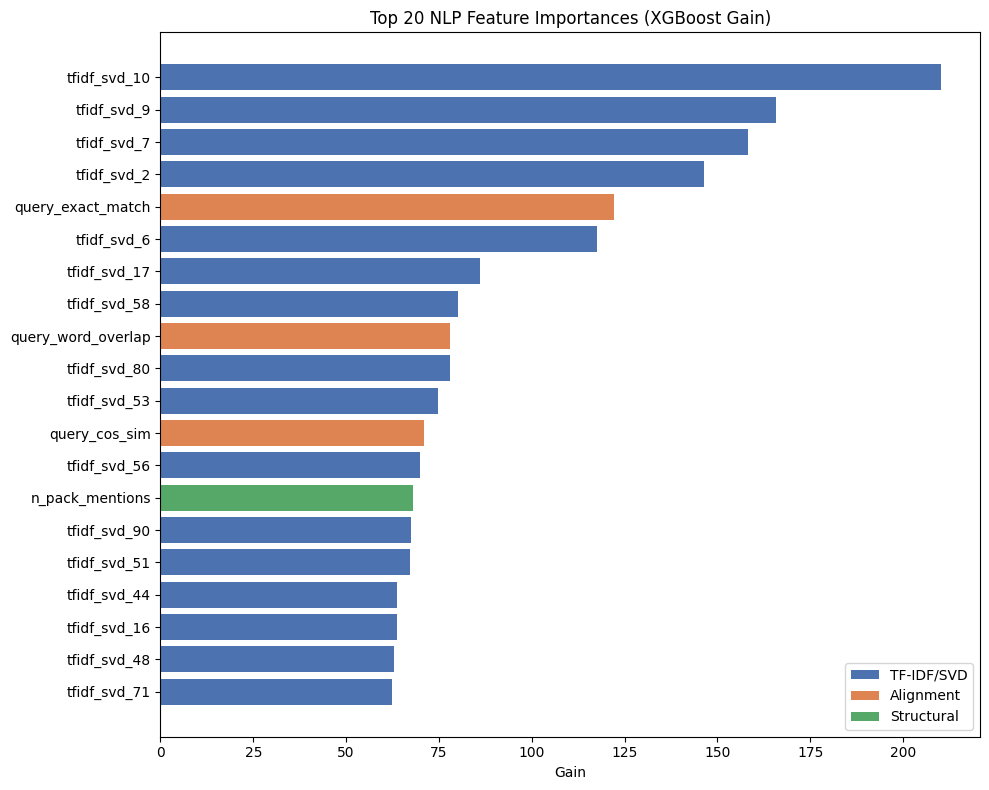

In [14]:
# Which features did XGBoost find most useful
import matplotlib.pyplot as plt

# Get feature importance from the full model (already trained above)
importance = model.get_booster().get_score(importance_type='gain')

feat_imp = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values('importance', ascending=False)

# XGBoost renames columns to f0, f1, etc.
feat_imp['feature'] = feat_imp['feature'].apply(
    lambda f: full_features[int(f.replace('f', ''))] if f.startswith('f') else f
)

print('Top 15 most important NLP features:')
print(feat_imp.head(15)[['feature', 'importance']].to_string(index=False))
print()

# Label which group each feature belongs to
def get_group(feat):
    if feat.startswith('tfidf_svd'): return 'TF-IDF/SVD'
    if feat in alignment_cols: return 'Alignment'
    return 'Structural'

feat_imp['group'] = feat_imp['feature'].apply(get_group)
group_totals = feat_imp.groupby('group')['importance'].sum().sort_values(ascending=False)
print('Total importance by feature group:')
print(group_totals.to_string())
print()

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 8))
top20 = feat_imp.head(20)
colors = top20['group'].map({'TF-IDF/SVD': '#4C72B0', 'Alignment': '#DD8452', 'Structural': '#55A868'})
ax.barh(range(len(top20)), top20['importance'], color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'])
ax.invert_yaxis()
ax.set_title('Top 20 NLP Feature Importances (XGBoost Gain)')
ax.set_xlabel('Gain')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='TF-IDF/SVD'),
    Patch(facecolor='#DD8452', label='Alignment'),
    Patch(facecolor='#55A868', label='Structural'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()